# Kagome and extended-kagome flat-band bandwidth and bandgap

Extract each `extkag_<n>_shb.csv` COMSOL export and calculate the flat-band bandwidth and its global spectral gap to the dispersive bands. The $n=0$ file is Kagome; files with $n>0$ are extended Kagome.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

from defs import band_frequency_matrix, extract_band_structure

In [22]:
data_dir = Path('../../../data/simulation')
out_dir = Path('../../../output/paper_upload')

# Plot output toggles
SHOW_PLOT_DECORATIONS = False  # False hides labels, tick labels, legends, and titles.
SAVE_PLOT = True  # False displays figures without saving them.

def selected_band_count(intercell_sites):
    return 3 if intercell_sites == 0 else 8 + 6 * intercell_sites

## Discover the simulation files

In [23]:
filename_pattern = re.compile(r'^extkag_(\d+)_shb\.csv$')
band_files = {}

for csv_path in data_dir.glob('extkag_*_shb.csv'):
    match = filename_pattern.match(csv_path.name)
    if match is None:
        continue

    intercell_sites = int(match.group(1))
    if intercell_sites in band_files:
        raise ValueError(
            f'Multiple files found for n={intercell_sites}'
        )
    band_files[intercell_sites] = csv_path

band_files = dict(sorted(band_files.items()))
print(f'Found {len(band_files)} band-structure files')
for intercell_sites, csv_path in band_files.items():
    print(f'  n={intercell_sites}: {csv_path.name}')

Found 5 band-structure files
  n=0: extkag_0_shb.csv
  n=1: extkag_1_shb.csv
  n=2: extkag_2_shb.csv
  n=3: extkag_3_shb.csv
  n=4: extkag_4_shb.csv


## Extract and organize the eigenfrequencies

In [24]:
band_data = {
    intercell_sites: extract_band_structure(
        csv_path, max_bands=selected_band_count(intercell_sites)
    )
    for intercell_sites, csv_path in band_files.items()
}

for intercell_sites, dataset in band_data.items():
    b_count, band_count = band_frequency_matrix(dataset).shape
    print(
        f'n={intercell_sites}: selected the {band_count} lowest bands '
        f'at {b_count} b values'
    )

n=0: selected the 3 lowest bands at 48 b values
n=1: selected the 14 lowest bands at 48 b values
n=2: selected the 20 lowest bands at 48 b values
n=3: selected the 26 lowest bands at 48 b values
n=4: selected the 32 lowest bands at 48 b values


## Calculate the flat-band bandwidth and bandgap

The highest-frequency retained band is treated as the flat band. Its bandwidth is $f_\mathrm{max}-f_\mathrm{min}$, and its bandgap is the global spectral separation to the dispersive bands below it. If a dispersive band overlaps the flat-band frequency range, the reported bandgap is zero.

In [25]:
def calculate_flat_band_metrics(dataset):
    bands_hz = band_frequency_matrix(dataset)
    band_count = bands_hz.shape[1]
    # Bands are frequency-sorted, so the final retained band is flat.
    flat_band_index = band_count - 1
    flat_band_hz = bands_hz[:, flat_band_index]

    candidate_gaps_hz = {}
    if flat_band_index > 0:
        candidate_gaps_hz['below'] = (
            flat_band_hz.min()
            - bands_hz[:, :flat_band_index].max()
        )
    if flat_band_index < band_count - 1:
        candidate_gaps_hz['above'] = (
            bands_hz[:, flat_band_index + 1:].min()
            - flat_band_hz.max()
        )
    if not candidate_gaps_hz:
        raise ValueError('At least one dispersive band is required')

    nearest_side = min(candidate_gaps_hz, key=candidate_gaps_hz.get)
    signed_bandgap_hz = candidate_gaps_hz[nearest_side]

    return {
        'flat_band_index': flat_band_index,
        'minimum_hz': flat_band_hz.min(),
        'maximum_hz': flat_band_hz.max(),
        'bandwidth_hz': np.ptp(flat_band_hz),
        'bandgap_hz': max(0.0, signed_bandgap_hz),
        'nearest_side': nearest_side,
        'signed_gaps_hz': candidate_gaps_hz,
    }

In [26]:
flat_band_metrics = {
    intercell_sites: calculate_flat_band_metrics(dataset)
    for intercell_sites, dataset in band_data.items()
}

for intercell_sites, metrics in flat_band_metrics.items():
    print(
        f'n={intercell_sites}: '
        f'bandwidth={metrics["bandwidth_hz"]:.6g} Hz, '
        f'bandgap={metrics["bandgap_hz"]:.6g} Hz '
        f'({metrics["nearest_side"]})'
    )

n=0: bandwidth=302.63 Hz, bandgap=0 Hz (below)
n=1: bandwidth=0.000771061 Hz, bandgap=177.225 Hz (below)
n=2: bandwidth=0.000431025 Hz, bandgap=588.919 Hz (below)
n=3: bandwidth=2.43423e-05 Hz, bandgap=708.115 Hz (below)
n=4: bandwidth=1.91783e-05 Hz, bandgap=739.844 Hz (below)


### Flat-band results table

In [27]:
results_table_lines = [
    '| Intercell sites | Flat-band frequency range (kHz) | Flat-band width (Hz) | Bandgap (Hz) |',
    '|--:|--:|--:|--:|',
]

for intercell_sites, metrics in flat_band_metrics.items():
    frequency_range_khz = (
        f'{metrics["minimum_hz"] / 1e3:.6f}–'
        f'{metrics["maximum_hz"] / 1e3:.6f}'
    )
    results_table_lines.append(
        f'| {intercell_sites} | {frequency_range_khz} | '
        f'{metrics["bandwidth_hz"]:.6g} | '
        f'{metrics["bandgap_hz"]:.6g} |'
    )

results_table_markdown = '\n'.join(results_table_lines)
display(Markdown(results_table_markdown))

| Intercell sites | Flat-band frequency range (kHz) | Flat-band width (Hz) | Bandgap (Hz) |
|--:|--:|--:|--:|
| 0 | 14.294025–14.596655 | 302.63 | 0 |
| 1 | 14.413364–14.413365 | 0.000771061 | 177.225 |
| 2 | 14.406764–14.406764 | 0.000431025 | 588.919 |
| 3 | 14.407690–14.407690 | 2.43423e-05 | 708.115 |
| 4 | 14.430646–14.430646 | 1.91783e-05 | 739.844 |

In [28]:
intercell_site_counts = np.asarray(sorted(flat_band_metrics))
bandgaps_hz = np.asarray([
    flat_band_metrics[n]['bandgap_hz']
    for n in intercell_site_counts
])
bandwidths_hz = np.asarray([
    flat_band_metrics[n]['bandwidth_hz']
    for n in intercell_site_counts
])

## Plot the results

In [ ]:
def plot_metric(values, *, yscale='linear', yticks=None):
    fig, ax = plt.subplots(figsize=(2, 1.5), tight_layout=True)
    ax.plot(
        intercell_site_counts, values,
        color='black', linestyle=':', linewidth=0.5,
    )
    ax.plot(
        intercell_site_counts, values,
        color='blue', linestyle='none', marker='.', markersize=5,
    )
    ax.set_yscale(yscale)
    ax.set_xticks(intercell_site_counts)
    if yticks is not None:
        ax.set_yticks(yticks)

    ax.tick_params(
        axis='both', width=0.25, length=1,
    )
    for spine in ax.spines.values():
        spine.set_linewidth(0.25)

    if not SHOW_PLOT_DECORATIONS:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title('')
        ax.tick_params(axis='x', labelbottom=False)
        ax.tick_params(axis='y', labelleft=False)
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    return fig, ax

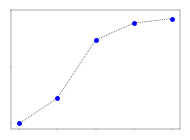

In [30]:
if intercell_site_counts.size:
    fig, ax = plot_metric(
        bandgaps_hz, yticks=np.linspace(0, 800, 3)
    )
    plt.show()
    if SAVE_PLOT:
        fig.savefig(out_dir / 'extkag_bandgap.pdf', bbox_inches='tight')
else:
    print('No bandgap data to plot yet')

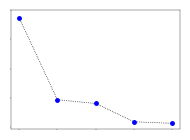

In [37]:
if intercell_site_counts.size:
    fig, ax = plot_metric(
        bandwidths_hz,
        yscale='log',
        yticks=10 ** np.linspace(-5, 3, 5),
    )
    plt.show()
    if SAVE_PLOT:
        fig.savefig(out_dir / 'extkag_bandwidth.pdf', bbox_inches='tight')
else:
    print('No bandwidth data to plot yet')